In [153]:
import pandas as pd
import numpy as np

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, precision_score

# Misc tools
from tqdm.notebook import tqdm
import os
import re
import time
import warnings
warnings.filterwarnings("ignore")

In [154]:
ml_df = pd.read_pickle('2023-04-04_NB4_ml_df.pkl')

To determine the appropriate models and hyper-parameters to implement into our pipeline, we will examine each model using the following protocol:

Goal: Identify the ideal models and hyper-parameter optimization ranges to implement into gridsearchCV to not waste computing time on testing every model with every range of parameter optimization values.

1. Fit the model to our data once using default hyper-parameter settings to gauge a baseline training and testing accuracy.
2. 
3. Investigate possible sources of error 
3. Perform a raster-scan fitting of a large range of hyper-parameters to determine an 

`ml_df` is our data set for performing machine learning. Here the target column is `PubTier`, which is the tier that each citation is classified in, while the remaining statistics for the first, second and third authors are the features.

In [155]:
ml_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 16029 entries, 0 to 16028
Data columns (total 45 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   PubTier                           16029 non-null  int8   
 1   first_auth_Mean_AuthorRank        16029 non-null  float16
 2   first_auth_Mean_Cites             16029 non-null  float16
 3   first_auth_Mean_Year              16029 non-null  float16
 4   first_auth_Mean_CitesPerYear      16029 non-null  float16
 5   first_auth_Mean_CitesPerAuthor    16029 non-null  float16
 6   first_auth_Mean_AuthorCount       16029 non-null  float16
 7   first_auth_Mean_SJR               16029 non-null  float16
 8   first_auth_Mean_H index           16029 non-null  float16
 9   first_auth_Mean_PubTier           16029 non-null  float16
 10  first_auth_NumPapers_inDataset    16029 non-null  float16
 11  first_auth_Author_Hindex          16029 non-null  float16
 12  seco

## Model 1: Logistic Regression

### Initial Model Fitting
Let's fit a logistic regression model to our data once using default hyper-parameter settings to gauge a baseline training and testing accuracy and precision metrics. We will use a train-test split of `test_size` = 25%, set `solver` to `lbfgs` to specify the algorithm to when fitting the logistic regression model, and set `random_state`= 1 to ensure that the model can be replicated with the same results every time it is trained. The training and testing accuracy scores will be outputted.

In [156]:
# Define features and target colums
X_train = ml_df.drop('PubTier', axis = 1)
y_train = ml_df['PubTier']

# Perform train-test split
X_train, X_test, y_train, y_test =  train_test_split(X_train, y_train, test_size=0.25, random_state = 1)

In [157]:
# Sclae the data using a standard scaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [173]:
# 1. Instantiate model
logit = LogisticRegression(solver='lbfgs', random_state=1, C = 1)

# 2. Fit model
logit.fit(X_train_scaled, y_train);

# 3. Score model
train_score = logit.score(X_train_scaled, y_train)
test_score = logit.score(X_test_scaled, y_test)
diff = train_score-test_score

# Get class predictions
y_pred = logit.predict(X_test_scaled)
pre_score =  precision_score(y_test, y_pred, average='weighted')

print('Model Used: Logistic Regression')
print('Parameter Used:   C =', 1)
print('\n')
print('--- Results ---')
print('Score on Train: {:0.2%}'.format(train_score))
print('Score on Test: {:0.2%}'.format(test_score))
print('Difference Between Training and Test Scores: {:0.2%}'.format(diff))
print('Weighted Precision Score: {:0.2%}'.format(pre_score))

Model Used: Logistic Regression
Parameter Used:   C = 1


--- Results ---
Score on Train: 76.12%
Score on Test: 75.60%
Difference Between Training and Test Scores: 0.52%
Weighted Precision Score: 75.83%


With the default hyper-parameter settings (`C`= 1) the logistic regression model was able to fit the training data with 76.12% accuracy and the testing data with 75.60% accuracy, additionally, the difference between training and testing scores being < 1% suggests that there is minimal over-fitting which could hopefully be solved optimizing the weight of the cost function in for the assigned penalty (L2, in our case). The weighted precision score of 75.83% suggests that observations were classified into their correct class nearly 76% of the time, though there is much room for improvement.

### Optimizing Model Accuracy

#### Part 1: Addressing Multicollinearity
Since logistic regression is a linear classification model, before perform considering the landscape of hyper-parameters to increase model accuracy, we should first access the other potential issues that could hinder the accuracy of the model, such as multicollinearity.

We can investigate multicollinearities between features using a heat map.

In [159]:
ml_corr = ml_df.drop('PubTier', axis = 1).corr()

Text(0.5, 1.0, 'Absolute Value of Correlations Between Features')

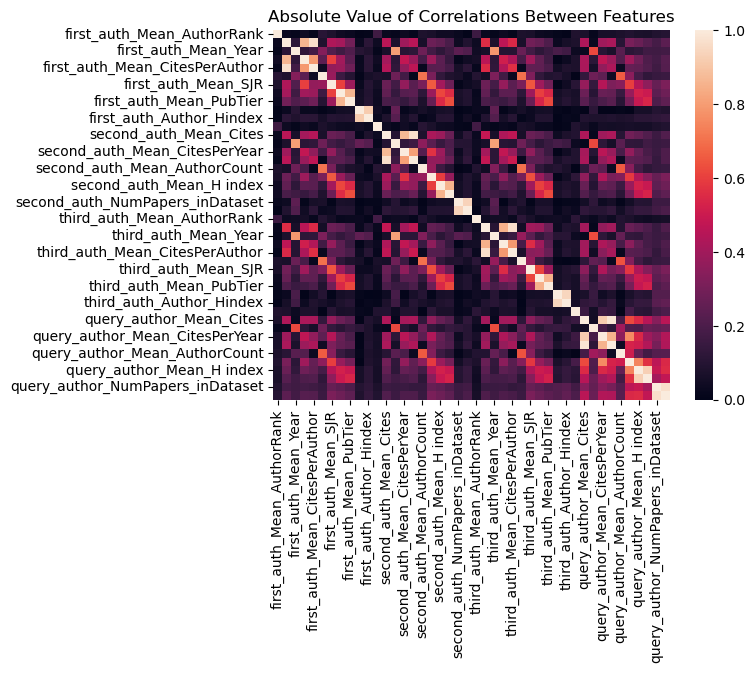

In [160]:
sns.heatmap(np.abs(ml_corr), vmin = 0, vmax = 1)
plt.title('Absolute Value of Correlations Between Features')

From the heatmap, we see that there are areas where collinearity between features is strong, i.e., > 0.5. Let's rescale the heatmap to highlight those collinearities.

Text(0.5, 1.0, 'Absolute Value of Correlations Between Features\nRescaled to Feature Correlations >= 0.5')

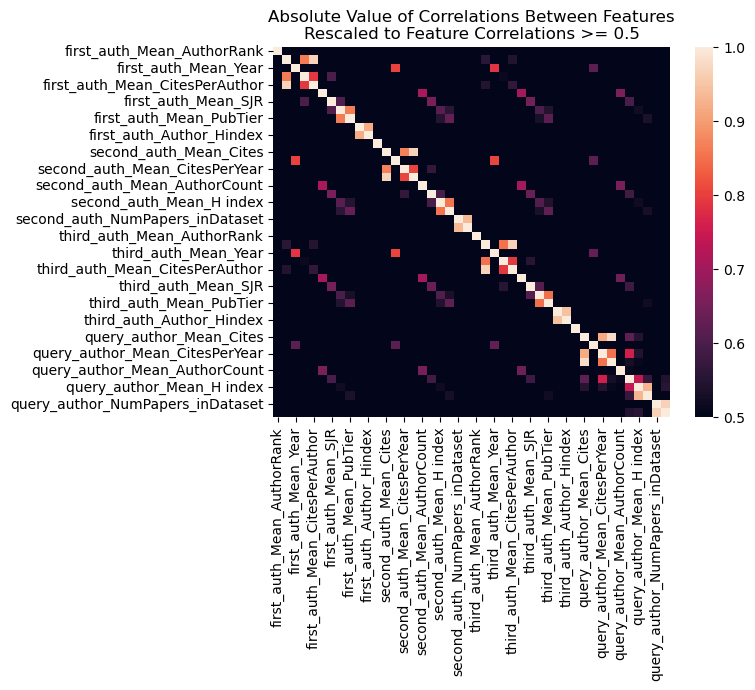

In [161]:
sns.heatmap(np.abs(ml_corr), vmin = 0.5, vmax = 1)
plt.title('Absolute Value of Correlations Between Features\nRescaled to Feature Correlations >= 0.5')

From this rescaled heat map, we see that most of the features have a correlation to another feature that has an absolute value over 0.5, with some features have correlations to another feature with a value over 0.8. Since our data set has < 50 features and most of the features attributes to the multicollinearity, removing select features through feature selection is unlikely going to solve multicollinearity issue. Instead, removing what limited features the model does have could result in the model being less generalizable if the limited columns selected do not adequately capture the variance in the data set. Overall, given the wide-spread multicollinearity and limited number of features, pursuing logistic regression as our classification model may not be ideal. 

However, we could employ a method of dimensionality reduction, such as principal vector component analysis (PCA) to reduce the number of columns, which could reduce multicollinearity, while preserving the variance in the data set. The effectiveness of PCA at capturing the variance of the data set can be quantified using the *explained variance ratio* for each of principle component (PC) describe the variation in the data set. Specifically, the explained variance ratio describes the *percentage* of the variance that each PC is able to account for, with the goal of increasing the number of PCs until all the variance in the data set can be adequately captured.

We can identify the number of PCs that adequately capture the variance in our data set by making a line plot of the explained variance ratios and identifying the elbow in the plot to decide how many PCs are  adequate. The number of PCs at the elbow in the plot will identify the threshold for where any additional PCs will not substantially raise the explained variance, and are therefore redundant at explaining the variance in the data set.

The number of PCs can be controlled using the `n_components` hyper-parameter. Let's examine how the number of principal components by examining the *explained variance ratios* for each.

In [162]:
n_list = np.arange(2, 40, 2)
EVR_list = []

for n in n_list:
    # Initiate PCA Model
    my_PCA = PCA(n_components = n)

    # Fit to training data
    my_PCA.fit(X_train_scaled)

    # Transform Training and Testing data
    X_train_PCA = my_PCA.transform(X_train_scaled)
    X_test_PCA = my_PCA.transform(X_test_scaled)
    EVR = my_PCA.explained_variance_ratio_
    EVR_list.append(EVR)

In [163]:
# Turing the list into an array with the explained variance of each PCA component
EVR_arr = np.zeros(n_list.shape[0])
for i in range(n_list.shape[0]):
    EVR_arr[i] = EVR_list[i][i]

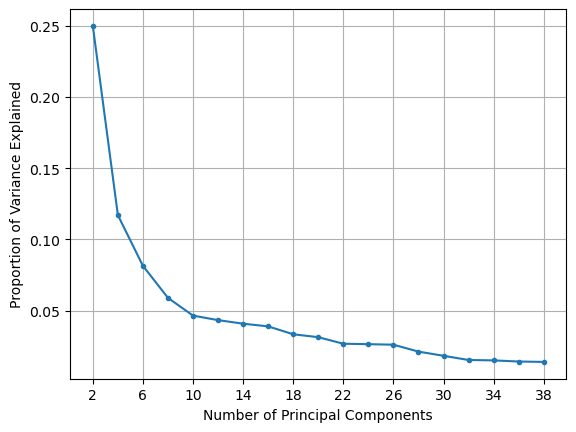

In [164]:
plt.plot(n_list, EVR_arr, marker = '.')
plt.xlabel('Number of Principal Components')
plt.ylabel('Proportion of Variance Explained')
plt.grid()
x_ticks = np.arange(2, 40, 4)
plt.xticks(x_ticks, x_ticks);

Here we see that the elbow in the plot is between 6-10 PCs suggesting that any additional PCs added beyond that will not substantially raise the explained variance. However, it appears that the explained variance ratio does not truly become constant until beyond 30 PCs so that the ideal number of PCs is anywhere between 6-30. This may be worth exploring during a grid search, but first we need to address if reducing the number of features using PCA will address the issue with multicollinearity. Let's look at a heat map of the PCA components for `n_components` = 6 and `n_components` = 30 to investigate.

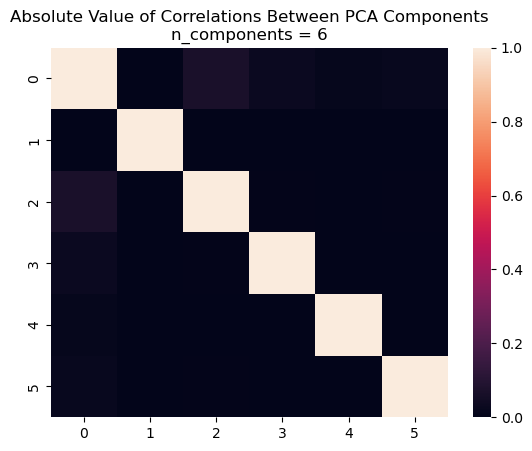

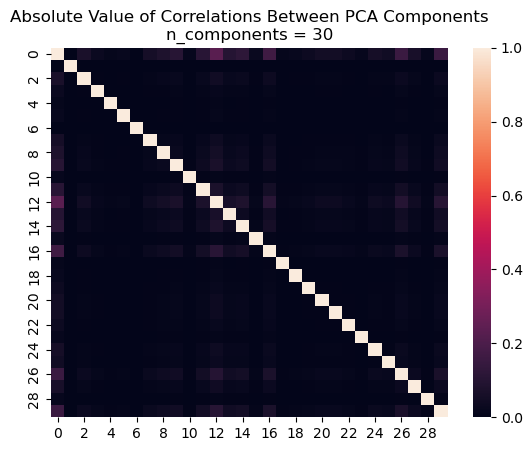

In [165]:
for i in [6, 30]:
    # Initiate PCA Model
    my_PCA = PCA(n_components = i)

    # Fit to training data
    my_PCA.fit(X_train);

    # Converting to DF to get correlation matrix. Transposing the array so that components are the columns.
    pca_corr = pd.DataFrame(my_PCA.components_.T).corr()

    sns.heatmap(np.abs(pca_corr), vmin = 0, vmax = 1)
    plt.title(f'Absolute Value of Correlations Between PCA Components\nn_components = {i}')
    plt.show()

From these results we observe that there are no longer any columns that have a correlation of > 0.5 for both the lower bound of `n_components` = 6 and upper bound of `n_components` = 30. These results suggests that any number of components between 6 and 30 selected by the grid search would not result in features that have strong correlations in between them, therefore suggesting the logistic regression could still be a feasible model for the data set when PCA in employed.

#### Part 2: Addressing Overfitting

We can optimize the hyper-parameter `C` in the logistic regression model in order to optimize the weight of the cost function. Let's examine how the training and testing accuracy changes for values of `C` over a large range ($10^{-5},10^{5}$).

In [166]:
c_vals = np.asarray([10**i for i in range(-5, 5)])
test_scores = []
train_scores = []

for c in c_vals:
    # 1. Instantiate model
    logit = LogisticRegression(solver='lbfgs', random_state=1, C = c)

    # 2. Fit model
    logit.fit(X_train_scaled, y_train);

    # 3. Score model
    train_score = logit.score(X_train_scaled, y_train)
    test_score = logit.score(X_test_scaled, y_test)
    train_scores.append(train_score)
    test_scores.append(test_score)

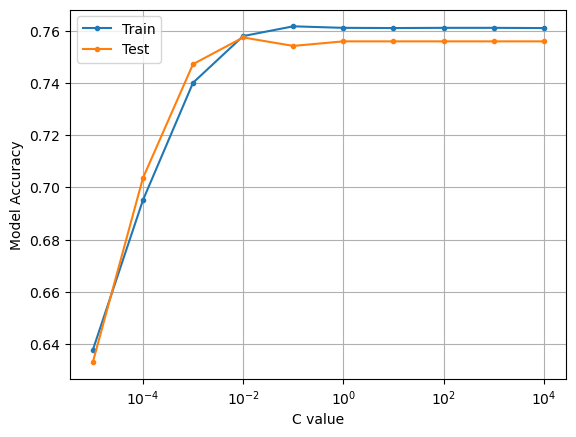

In [167]:
plt.plot(c_vals, train_scores, marker = '.', label = 'Train')
plt.plot(c_vals, test_scores, marker = '.', label = 'Test')
plt.xscale('log')
plt.xlabel('C value')
plt.ylabel('Model Accuracy')
plt.legend()
plt.grid()

From these results, we see that logistic regression model suffers from *under fitting* for `C` $< 10^{-2}$ and switches to suffering from over fitting from `C` $> 10^{-2}$. It appears that the least amount of over and under fitting occurs at `C` $= 10^{-2}$, so a grid search for the optimal C values could be around `C` $= 10^{-2}$ (range of 0.005 to 0.0105, for example).

To further isolate the optimal range of `C` values for grid searching, let's apply the same analysis for the `C` values for the data set reduced using PCA with the lower bound `n_components` = 6 and upper bound `n_components` = 30.

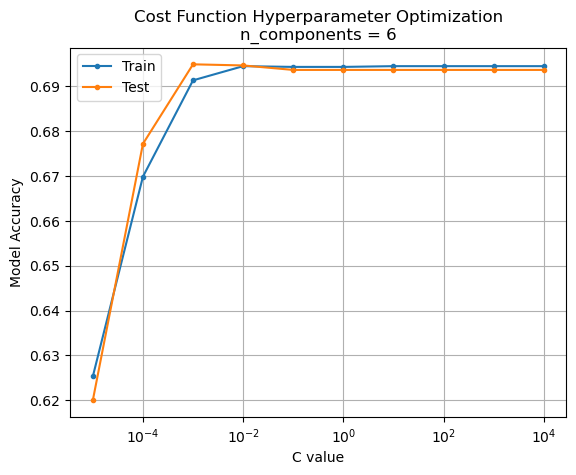

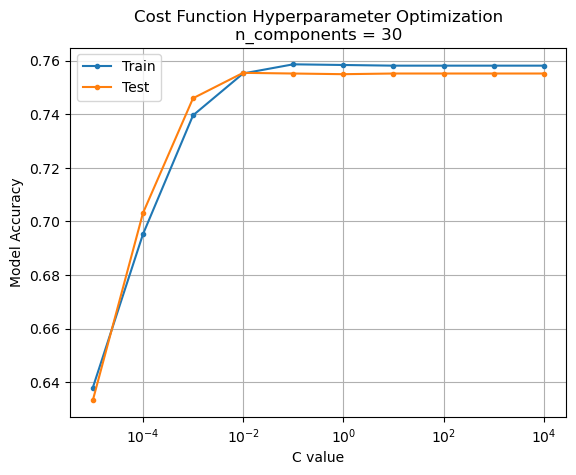

In [171]:
c_vals = np.asarray([10**i for i in range(-5, 5)])

for i in [6, 30]:
    # Initiate PCA Model
    my_PCA = PCA(n_components = i)

    # Fit to training data
    my_PCA.fit(X_train_scaled);
    
    X_train_PCA = my_PCA.transform(X_train_scaled)
    X_test_PCA = my_PCA.transform(X_test_scaled)
    
    test_scores = []
    train_scores = []

    for c in c_vals:
        # 1. Instantiate model
        logit = LogisticRegression(solver='lbfgs', random_state=1, C = c)

        # 2. Fit model
        logit.fit(X_train_PCA, y_train);

        # 3. Score model
        train_score = logit.score(X_train_PCA, y_train)
        test_score = logit.score(X_test_PCA, y_test)
        train_scores.append(train_score)
        test_scores.append(test_score)
        
    plt.plot(c_vals, train_scores, marker = '.', label = 'Train')
    plt.plot(c_vals, test_scores, marker = '.', label = 'Test')
    plt.xscale('log')
    plt.xlabel('C value')
    plt.ylabel('Model Accuracy')
    plt.legend()
    plt.title(f'Cost Function Hyperparameter Optimization\nn_components = {i}')
    plt.grid()
    plt.show()

We get similar results the data set reduced using PCA with the lower bound `n_components` = 6 and upper bound `n_components` = 30 as we did the original data set, such as the logistic regression model suffers from *under fitting* for `C` $< 10^{-2}$ and switches to suffering from over fitting from `C` $> 10^{-2}$. However, for the data set reduced using `n_components` = 6, the under fitting for `C` $< 10^{-2}$  is much more exaggerated at `C` $<= 10^{-1}$ than the other two examples. Overall, this finding further supports the range of values for `C` for grid search to consider to be closer to $10^{-2}$ than $10^{-3}$ and $10^{-1}$ to optimize model fitting.

---

## Model 2: KNN Classifers

### Initial Fitting
Let's fit a K nearest-neighbor (KNN) model to our data once using default hyper-parameter settings to gauge a baseline training and testing accuracy and precision metrics. We will use the same train-test split with `test_size` = 25% as was used for the logistic regression model, as well as the feature columns scaled using `StandardScalar`. 

In [169]:
# 1. Instantiate model
knn = KNeighborsClassifier()

# 2. Fit model
knn.fit(X_train_scaled, y_train);

# 3. Score model
train_score = knn.score(X_train_scaled, y_train)
test_score = knn.score(X_test_scaled, y_test)
diff = train_score-test_score

# Get class predictions
y_pred = knn.predict(X_test_scaled)
pre_score =  precision_score(y_test, y_pred, average='weighted')

print('Model Used: KNN')
print('Parameter Used:  n_neighbors =', 5)
print('\n')
print('--- Results ---')
print('Score on Train: {:0.2%}'.format(train_score))
print('Score on Test: {:0.2%}'.format(test_score))
print('Difference Between Training and Test Scores: {:0.2%}'.format(diff))
print('Weighted Precision Score: {:0.2%}'.format(pre_score))

Model Used: KNN
Parameter Used:  n_neighbors = 5


--- Results ---
Score on Train: 78.06%
Score on Test: 66.92%
Difference Between Training and Test Scores: 11.14%
Weighted Precision Score: 68.00%


With the default hyper-parameter settings (`n_neighbors`= 5) the KNN model was able to fit the training data with 78.06% accuracy and the testing data with 66.92% accuracy. Unlike the logistic regression model, the difference between training and testing scores was over > 1%. In fact, the difference was > 10% (11.14%) suggesting there is most over fitting in the KNN model with the default parameters than the logistic regression model. The weighted precision score of 68.00% suggests that observations were classified into their correct class nearly 68% of the time, which is also a lower percentage of precision compared to that of the logistic regression model (78%). These results conclude that logistic regression may be the ideal model for classifying the citations into publication tiers, however let's test to see if changing the value of `n_neighbors` could increase the KNN model accuracy.

### Optimizing Model Accuracy

Let's see the model accuracy for KNN changes with integer step-size values of `n_neighbors` over a range of 5 to 20.

In [172]:
n_list = np.arange(5, 43, 2)
test_scores = []
train_scores = []

for n in tqdm(n_list):
    # 1. Instantiate model
    knn = KNeighborsClassifier(n_neighbors = n)

    # 2. Fit model
    knn.fit(X_train_scaled, y_train);
    
    # 3. Score model
    train_score = knn.score(X_train_scaled, y_train)
    test_score = knn.score(X_test_scaled, y_test)
    train_scores.append(train_score)
    test_scores.append(test_score)

  0%|          | 0/19 [00:00<?, ?it/s]

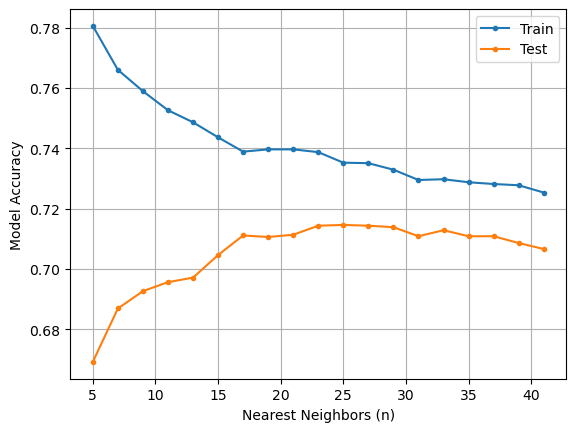

In [174]:
plt.plot(n_list, train_scores, marker = '.', label = 'Train')
plt.plot(n_list, test_scores, marker = '.', label = 'Test')
plt.xlabel('Nearest Neighbors (n)')
plt.ylabel('Model Accuracy')
plt.legend()
plt.grid()

From the results, we observe the training and testing accuracy converging towards 0.72 as `n_neighbors` increases. Although past `n_neighbors` = 35, the testing accuracy starts to diverge from 0.72, which would be consistent with the model having a greater tendency to over fit when the `n_neighbors` reaching the number of features in the data set (44). Overall, from this analysis, it appears that changing the values of `n_neighbors` would not decrease the gap between the training and testing accuracy doesn't decrease below 1% as it did for logistic regression. Therefore, including KNN in the grid search pipeline to fine the best model would not be a efficient use of computational time.

---

## Model 3: Decision Tree